industry_index – индексы промышленного производства по субъектам, %

capital_investments – доля инвестиций в основной капитал к ВРП, %

load_capacity_grp – грузоёмкость ВРП, тонн-км/долл. США

secondary_sector – доля обрабатывающих производств, %

labour_productivity – производительность труда, %

employment – уровень занятости, %

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from matplotlib.patches import Patch
from sklearn.preprocessing import StandardScaler
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score
import statsmodels.api as sm
from statsmodels.tsa.stattools import grangercausalitytests
from statsmodels.stats.outliers_influence import variance_inflation_factor
import scipy.stats as sps
import itertools
import warnings


In [2]:
with pd.ExcelFile('dataset.xlsx', engine='openpyxl') as file:
    industry_index = pd.read_excel(file, 'industry_index')
    capital_investments = pd.read_excel(file, 'capital_investments')
    load_capacity_grp = pd.read_excel(file, 'load_capacity_grp')
    secondary_sector = pd.read_excel(file, 'secondary_sector')
    labour_productivity = pd.read_excel(file, 'labour_productivity')
    employment = pd.read_excel(file, 'employment')
    the_whole_data = [industry_index, capital_investments, load_capacity_grp, secondary_sector, labour_productivity, employment]
    indicator_names = ['Индекс промышленного производства', 
                   'Инвестиции в основной капитал', 
                   'Грузоёмкость ВРП', 
                   'Доля обрабатывающих производств', 
                   'Производительность труда', 
                   'Уровень занятости']
    string_indicators = ['industry_index', 'capital_investments', 'load_capacity_grp', 'secondary_sector', 'labour_productivity', 'employment']

In [3]:
print('Индексы промышленного производства по субъектам, %')
print(industry_index.head())
print('\nДоля инвестиций в основной капитал к ВРП, %')
print(capital_investments.head())
print('\nГрузоёмкость ВРП, тонн-км/долл. США')
print(load_capacity_grp.head())
print('\nДоля обрабатывающих производств, %')
print(secondary_sector.head())
print('\nПроизводительность труда, %')
print(labour_productivity.head())
print('\nУровень занятости, %')
print(employment.head())

Индексы промышленного производства по субъектам, %
                Субъект   2018   2019   2020   2021   2022   2023 Округ
0  Белгородская область  102.4  103.9  101.7  104.4  102.1  104.7   ЦФО
1      Брянская область  102.7  117.0  102.0  112.2  120.8  115.8   ЦФО
2  Владимирская область  104.6  113.0  111.2  108.6  106.6  109.4   ЦФО
3   Воронежская область  103.2  111.3  109.5  105.5   98.0  109.9   ЦФО
4    Ивановская область  102.1  102.6  108.5  108.8  101.7  110.0   ЦФО

Доля инвестиций в основной капитал к ВРП, %
                Субъект  2018  2019  2020  2021  2022  2023 Округ
0  Белгородская область  14.8  17.5  17.0  12.4  15.3  15.8   ЦФО
1      Брянская область  16.0  15.9  18.2  17.3  16.6  15.2   ЦФО
2  Владимирская область  15.3  16.8  17.2  14.0  23.7  20.3   ЦФО
3   Воронежская область  29.1  29.8  24.4  22.4  25.2  25.0   ЦФО
4    Ивановская область  12.6  14.7  16.5  14.7  17.1  16.0   ЦФО

Грузоёмкость ВРП, тонн-км/долл. США
                Субъект    2018    2019

In [4]:
# индексы промышленного производства по субъектам, %
industry_index.describe()

,2018,2019,2020,2021,2022,2023
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,102.547126,105.433333,100.872414,107.043678,101.913793,107.197701
std,6.637943,10.506705,9.019806,6.401720,8.447776,7.891075
min,65.500000,92.200000,63.300000,88.600000,76.800000,92.900000
25%,100.300000,101.550000,96.400000,103.450000,97.900000,100.450000
50%,102.300000,103.700000,100.200000,106.300000,102.400000,107.100000
75%,105.050000,107.250000,105.100000,110.250000,105.300000,111.800000
max,117.000000,191.100000,130.900000,129.300000,137.400000,130.700000


In [5]:
# доля инвестиций в основной капитал к ВРП, %
capital_investments.describe()

,2018,2019,2020,2021,2022,2023
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,22.385057,22.665517,23.042529,20.264368,22.052874,23.189655
std,9.921313,9.368947,8.622222,7.728548,9.915490,11.111497
min,11.600000,12.700000,13.000000,9.500000,9.400000,8.000000
25%,16.650000,17.350000,18.250000,16.300000,16.550000,17.000000
50%,19.700000,19.900000,20.000000,18.500000,19.300000,19.800000
75%,25.750000,26.000000,26.100000,21.450000,24.500000,25.200000
max,75.200000,86.200000,80.200000,75.200000,80.900000,93.900000


In [6]:
# грузоёмкость ВРП, тонн-км/долл. США
load_capacity_grp.describe()

,2018,2019,2020,2021,2022,2023
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,0.197505,0.199795,0.203421,0.183235,0.159759,0.185239
std,0.236929,0.186508,0.187451,0.176603,0.117824,0.136549
min,0.006100,0.003300,0.007400,0.008300,0.006700,0.009200
25%,0.100800,0.099550,0.110700,0.095950,0.089100,0.102650
50%,0.154200,0.174200,0.181700,0.165200,0.156800,0.180400
75%,0.203500,0.227150,0.247500,0.221950,0.200750,0.210600
max,1.800400,1.265600,1.460800,1.410000,0.798300,0.808200


In [7]:
# доля обрабатывающих производств, %
secondary_sector.describe()

,2018,2019,2020,2021,2022,2023
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,16.505747,16.044828,16.512644,16.920690,16.468966,16.595402
std,10.818249,10.657291,10.777753,12.096705,11.159544,11.084516
min,0.200000,0.200000,0.200000,0.100000,0.100000,0.100000
25%,8.150000,7.950000,8.150000,7.650000,7.550000,7.750000
50%,15.800000,15.400000,15.600000,15.900000,16.000000,16.700000
75%,23.900000,24.400000,24.250000,24.000000,23.800000,23.450000
max,42.900000,38.300000,40.800000,53.800000,51.800000,51.000000


In [8]:
# производительность труда, %
labour_productivity.describe()

,2018,2019,2020,2021,2022,2023
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,102.710345,102.968966,101.214943,103.064368,99.694253,105.241379
std,2.947645,2.710587,4.308362,4.318726,4.334404,5.554833
min,94.300000,96.900000,86.100000,93.000000,89.600000,92.100000
25%,101.200000,101.300000,98.450000,100.400000,96.800000,101.650000
50%,102.800000,102.800000,100.700000,102.700000,99.800000,105.000000
75%,104.250000,104.300000,103.750000,104.850000,102.450000,107.950000
max,115.000000,114.300000,114.600000,119.900000,112.200000,127.700000


In [9]:
# уровень занятости, %
employment.describe()

,2018,2019,2020,2021,2022,2023
count,87.000000,87.000000,87.000000,87.000000,87.000000,87.000000
mean,58.928736,58.368966,57.344828,58.506897,59.036782,59.957471
std,4.589901,5.116419,5.350956,5.146952,4.697899,4.694743
min,50.000000,47.700000,43.400000,49.000000,50.800000,49.100000
25%,56.550000,55.600000,54.700000,56.200000,56.300000,57.000000
50%,58.100000,57.700000,56.800000,57.800000,58.500000,59.500000
75%,60.700000,60.350000,59.850000,60.800000,61.550000,62.250000
max,75.700000,77.700000,77.200000,78.000000,76.400000,77.800000


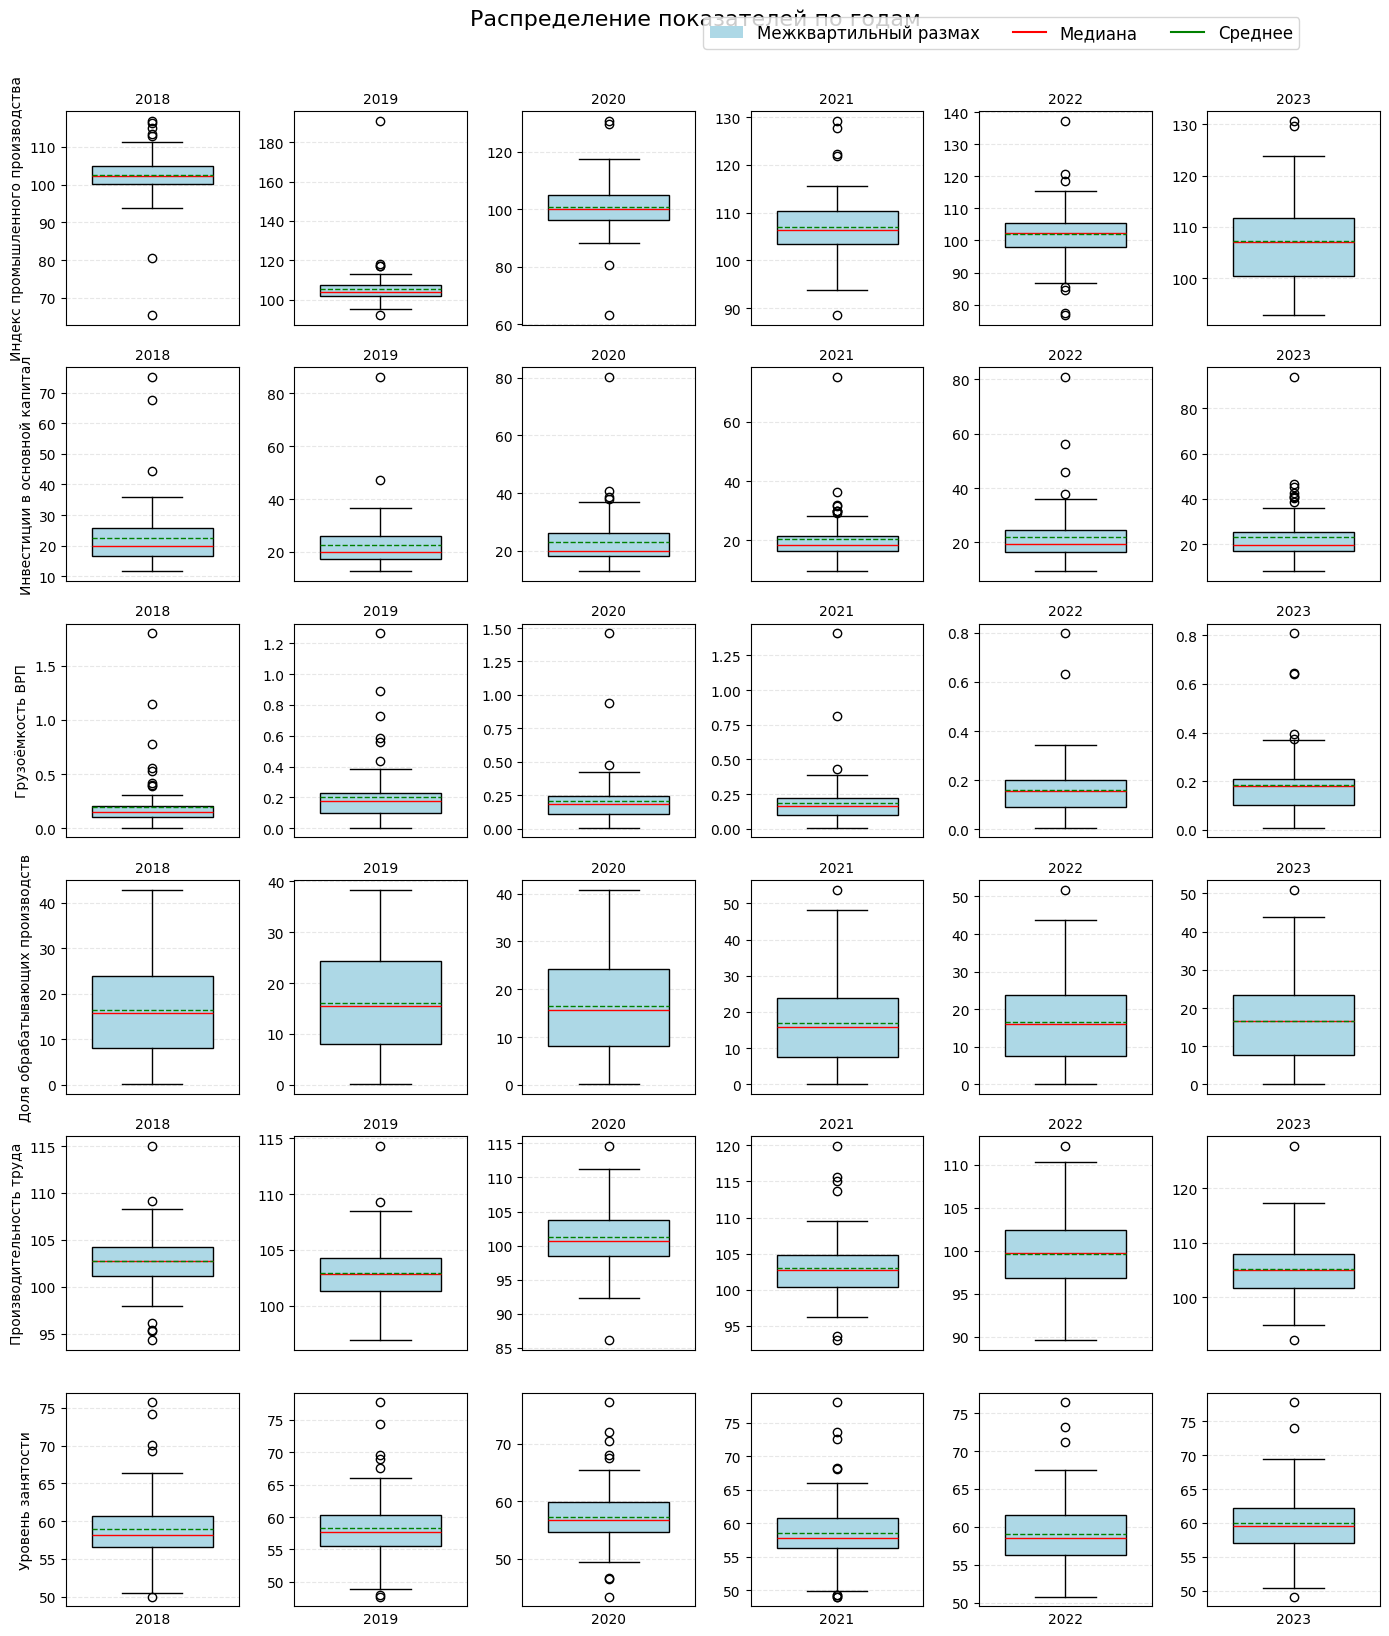

In [10]:
# Создаем фигуру с 6 строками и 5 столбцами
fig, axes = plt.subplots(6, 6, figsize=(14, 16))
fig.suptitle('Распределение показателей по годам', fontsize=16, y=1.02)

# Перебираем все показатели
for i, (indicator, name) in enumerate(zip(the_whole_data, indicator_names)):
    # Берем только столбцы с годами (исключая первый и последний, если нужно)
    # Предполагаем, что структура: [регион, 2019, 2020, 2021, 2022, 2023, что-то_еще]
    data_years = indicator.iloc[:, 1:-1]  # Берем столбцы с годами
    
    # Получаем список годов из названий столбцов
    years = data_years.columns.tolist()
    
    # Перебираем годы (столбцы) для текущего показателя
    for j, year in enumerate(years):
        ax = axes[i, j]
        
        # Строим boxplot для текущего года
        box = ax.boxplot(data_years[year].dropna(),  # Удаляем NaN
                         patch_artist=True,
                         widths=0.7,
                         showmeans=True,  # Показываем среднее
                         meanline=True,   # Линия для среднего
                         showfliers=True)  # Показываем выбросы
        
        # Настройка внешнего вида boxplot
        box['boxes'][0].set_facecolor('lightblue')
        box['medians'][0].set_color('red')
        box['means'][0].set_color('green')
        
        # Настройка осей и подписей
        if j == 0:  # Только для первого столбца
            ax.set_ylabel(name, fontsize=10)
        
        if i == 5:  # Только для последней строки
            ax.set_xlabel(year, fontsize=10)
        else:
            ax.set_title(year, fontsize=10)
        
        # Убираем лишние подписи на оси X
        ax.set_xticks([])
        
        # Добавляем сетку для удобства чтения
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Автоматическое масштабирование оси Y для лучшего отображения
        ax.autoscale_view()

# Настройка общего оформления
plt.tight_layout()


legend_elements = [
    Patch(facecolor='lightblue', label='Межквартильный размах'),
    plt.Line2D([0], [0], color='red', label='Медиана'),
    plt.Line2D([0], [0], color='green', label='Среднее')
]
fig.legend(handles=legend_elements, loc='upper left', 
           bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=12)

plt.show()

In [11]:
for indicator in the_whole_data:
    for year in range(2018, 2024):
        data = indicator[year]
        lower_bound = data.quantile(0.10)
        upper_bound = data.quantile(0.90)
        indicator[year] = data.clip(lower_bound, upper_bound)

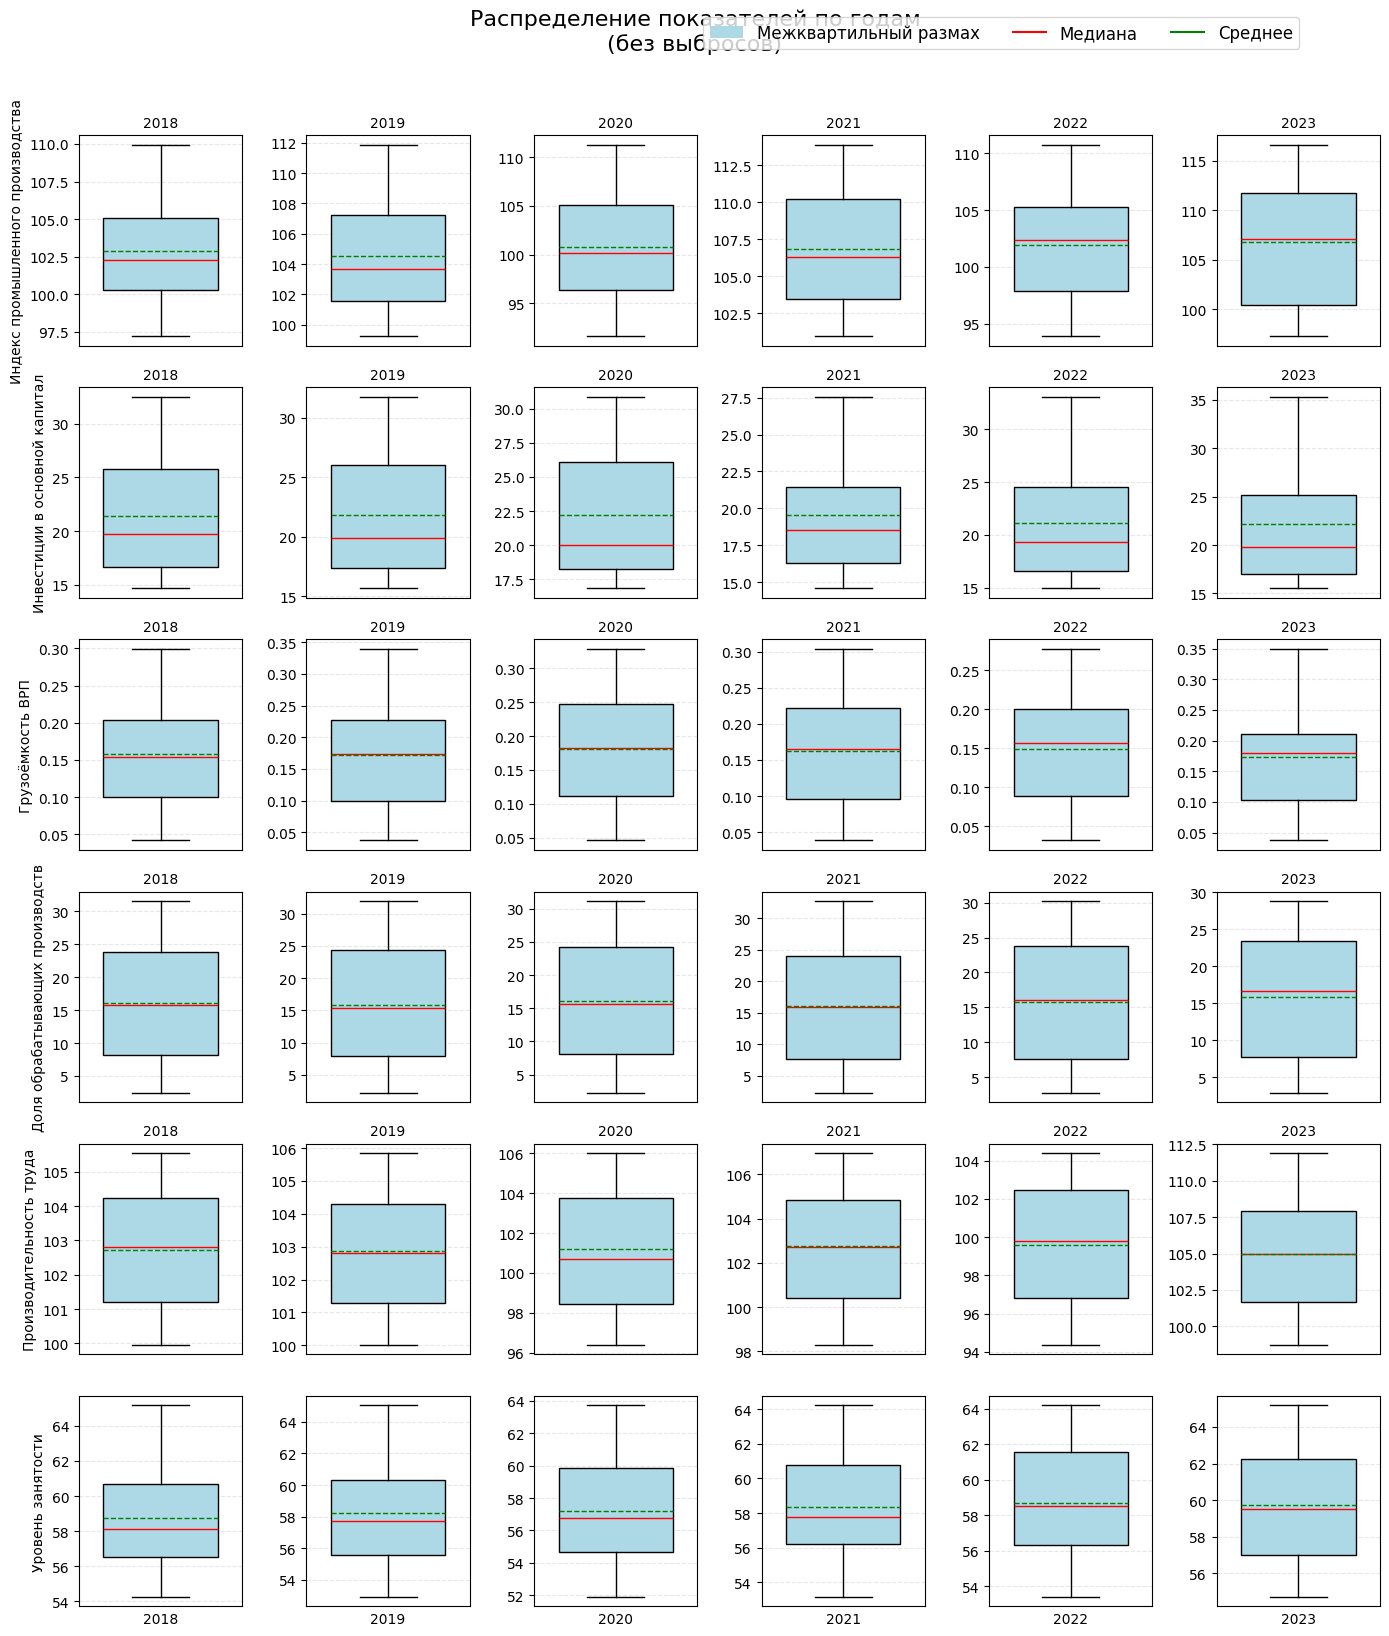

In [12]:
# Создаем фигуру с 6 строками и 5 столбцами
fig, axes = plt.subplots(6, 6, figsize=(14, 16))
fig.suptitle('Распределение показателей по годам\n(без выбросов)', fontsize=16, y=1.02)

# Перебираем все показатели
for i, (indicator, name) in enumerate(zip(the_whole_data, indicator_names)):
    # Берем только столбцы с годами (исключая первый и последний, если нужно)
    # Предполагаем, что структура: [регион, 2019, 2020, 2021, 2022, 2023, что-то_еще]
    data_years = indicator.iloc[:, 1:-1]  # Берем столбцы с годами
    
    # Получаем список годов из названий столбцов
    years = data_years.columns.tolist()
    
    # Перебираем годы (столбцы) для текущего показателя
    for j, year in enumerate(years):
        ax = axes[i, j]
        
        # Строим boxplot для текущего года
        box = ax.boxplot(data_years[year].dropna(),  # Удаляем NaN
                         patch_artist=True,
                         widths=0.7,
                         showmeans=True,  # Показываем среднее
                         meanline=True,   # Линия для среднего
                         showfliers=True)  # Показываем выбросы
        
        # Настройка внешнего вида boxplot
        box['boxes'][0].set_facecolor('lightblue')
        box['medians'][0].set_color('red')
        box['means'][0].set_color('green')
        
        # Настройка осей и подписей
        if j == 0:  # Только для первого столбца
            ax.set_ylabel(name, fontsize=10)
        
        if i == 5:  # Только для последней строки
            ax.set_xlabel(year, fontsize=10)
        else:
            ax.set_title(year, fontsize=10)
        
        # Убираем лишние подписи на оси X
        ax.set_xticks([])
        
        # Добавляем сетку для удобства чтения
        ax.grid(True, alpha=0.3, linestyle='--')
        
        # Автоматическое масштабирование оси Y для лучшего отображения
        ax.autoscale_view()

# Настройка общего оформления
plt.tight_layout()


legend_elements = [
    Patch(facecolor='lightblue', label='Межквартильный размах'),
    plt.Line2D([0], [0], color='red', label='Медиана'),
    plt.Line2D([0], [0], color='green', label='Среднее')
]
fig.legend(handles=legend_elements, loc='upper left', 
           bbox_to_anchor=(0.5, 1.02), ncol=3, fontsize=12)

plt.show()

In [13]:
average_df = pd.DataFrame(index=employment['Субъект'])
for key, indicator in zip(string_indicators, the_whole_data):
    average_df[key] = indicator.set_index('Субъект').iloc[:, :-1].mean(axis=1)

average_df.head()


,industry_index,capital_investments,load_capacity_grp,secondary_sector,labour_productivity,employment
Субъект,,,,,,
Белгородская область,103.200000,15.830000,0.278207,16.100000,101.750000,61.000000
Брянская область,109.220000,16.590000,0.276713,17.400000,103.716667,56.733333
Владимирская область,108.713333,17.980000,0.146683,31.016667,103.523333,59.866667
Воронежская область,106.233333,25.983333,0.272237,15.566667,100.650000,58.000000
Ивановская область,105.616667,15.833333,0.193050,21.950000,103.166667,58.550000


In [14]:
scaler = StandardScaler()
scaled_average_df = pd.DataFrame(scaler.fit_transform(average_df),
                                 index=average_df.index,
                                 columns=average_df.columns)
scaled_average_df.head()

,industry_index,capital_investments,load_capacity_grp,secondary_sector,labour_productivity,employment
Субъект,,,,,,
Белгородская область,-0.299591,-1.189817,1.379352,0.014806,-0.482442,0.753158
Брянская область,1.992483,-1.026929,1.361011,0.153967,1.084387,-0.527854
Владимирская область,1.799573,-0.729015,-0.235987,1.611592,0.930360,0.412889
Воронежская область,0.855330,0.986313,1.306030,-0.042286,-1.358803,-0.147553
Ивановская область,0.620538,-1.189102,0.333478,0.641032,0.646206,0.017577


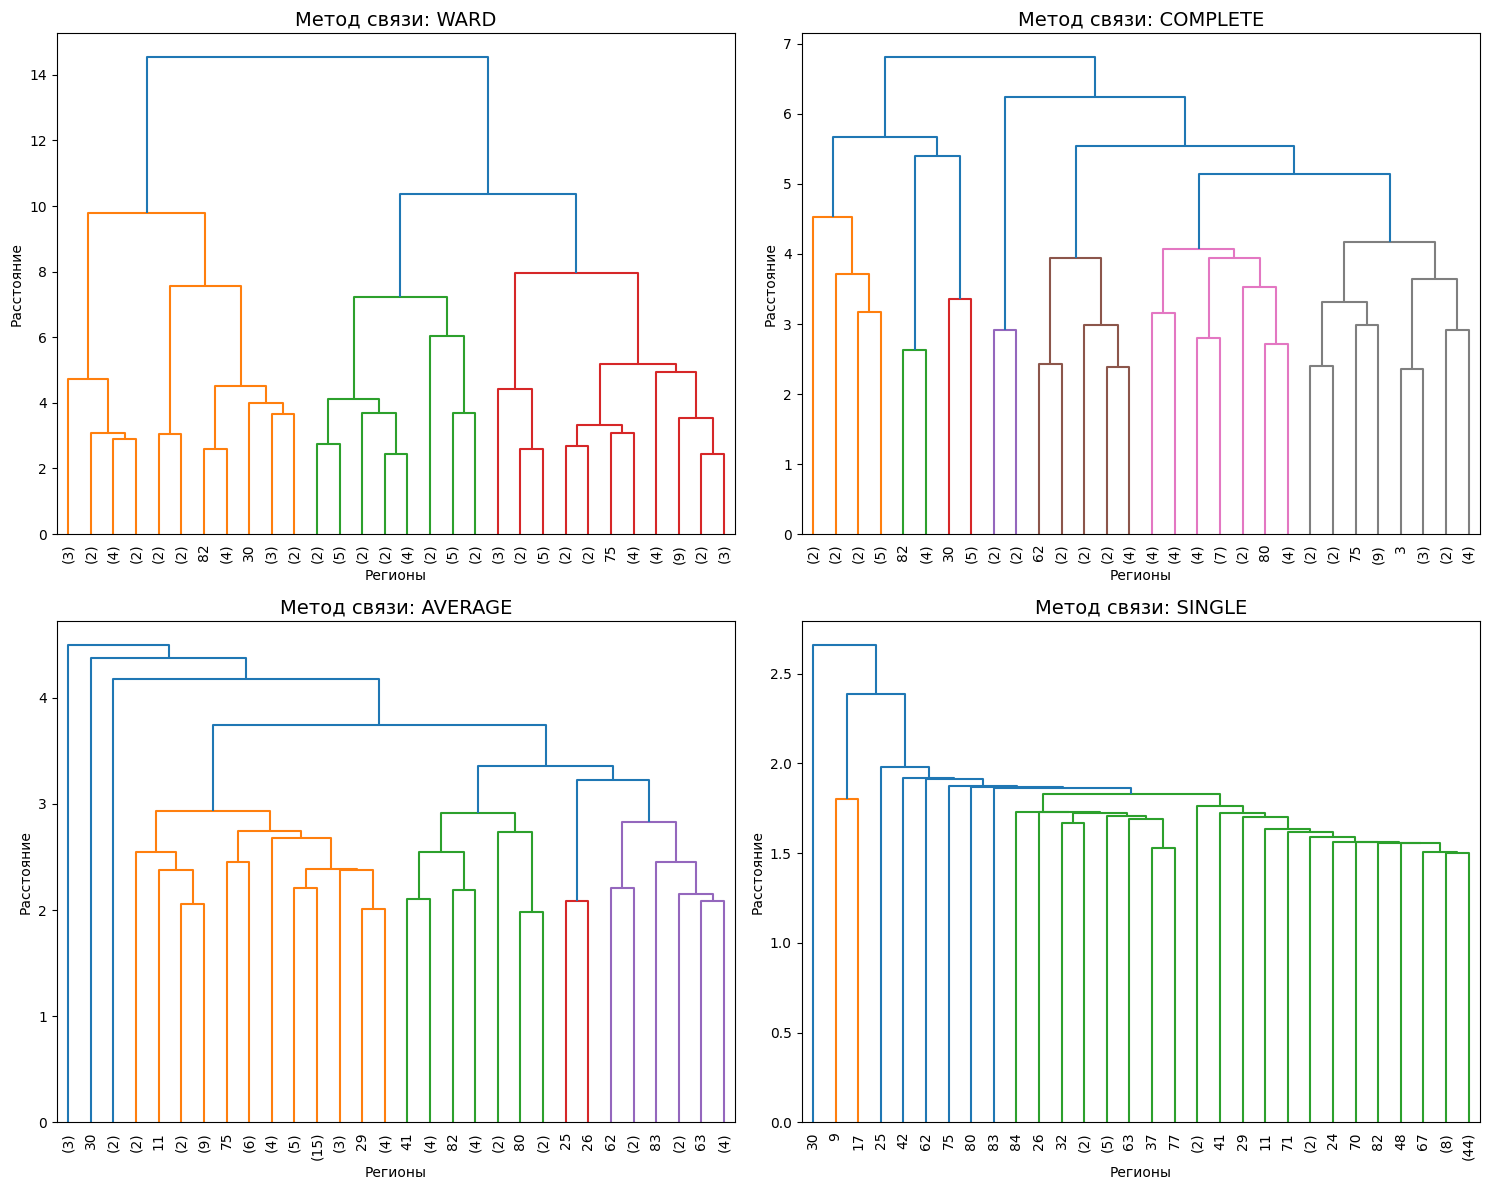

In [15]:
# Метрики для сравнения
from scipy.spatial.distance import pdist, squareform

# Рассчитываем матрицу расстояний
distance_matrix = pdist(scaled_average_df, metric='euclidean')

# Методы связи для сравнения
linkage_methods = ['ward', 'complete', 'average', 'single']

# Создаем фигуру для сравнения методов
fig, axes = plt.subplots(2, 2, figsize=(15, 12))
axes = axes.flatten()

for idx, method in enumerate(linkage_methods):
    # Выполняем иерархическую кластеризацию
    Z = linkage(scaled_average_df, method=method, metric='euclidean')
    
    # Строим дендрограмму
    ax = axes[idx]
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30, 
               show_leaf_counts=True, leaf_rotation=90)
    ax.set_title(f'Метод связи: {method.upper()}', fontsize=14)
    ax.set_xlabel('Регионы')
    ax.set_ylabel('Расстояние')

plt.tight_layout()
plt.show()

C:\Users\Илья\AppData\Local\Temp\ipykernel_5340\3116308603.py:17: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend()


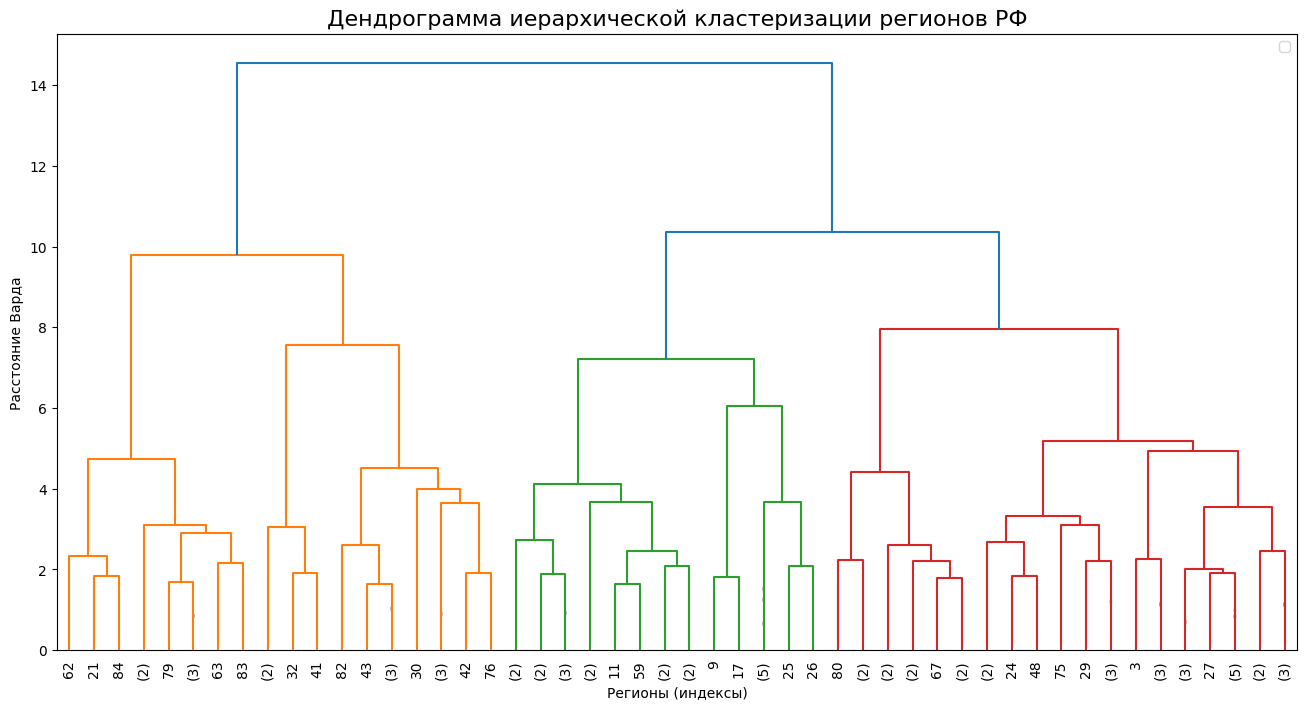

Распределение регионов по кластерам:
cluster
1    26
2    24
3    37
Name: count, dtype: int64


In [16]:
# Выбираем метод Варда (часто лучший для экономических данных)
Z = linkage(scaled_average_df, method='ward', metric='euclidean')

# Визуализируем полную дендрограмму
plt.figure(figsize=(16, 8))
dendrogram(Z, 
           truncate_mode='lastp',  # Показываем только последние p слитых кластеров
           p=50,  # Показываем 50 листьев
           show_leaf_counts=True,
           leaf_rotation=90,
           leaf_font_size=10,
           show_contracted=True)

plt.title('Дендрограмма иерархической кластеризации регионов РФ', fontsize=16)
plt.xlabel('Регионы (индексы)')
plt.ylabel('Расстояние Варда')
plt.legend()
plt.show()

# "Разрезаем" дендрограмму на 3 кластера
n_clusters = 3
clusters = fcluster(Z, n_clusters, criterion='maxclust')

# Добавляем метки кластеров в DataFrame
average_df['cluster'] = clusters
scaled_average_df['cluster'] = clusters

print(f"Распределение регионов по кластерам:")
print(average_df['cluster'].value_counts().sort_index())

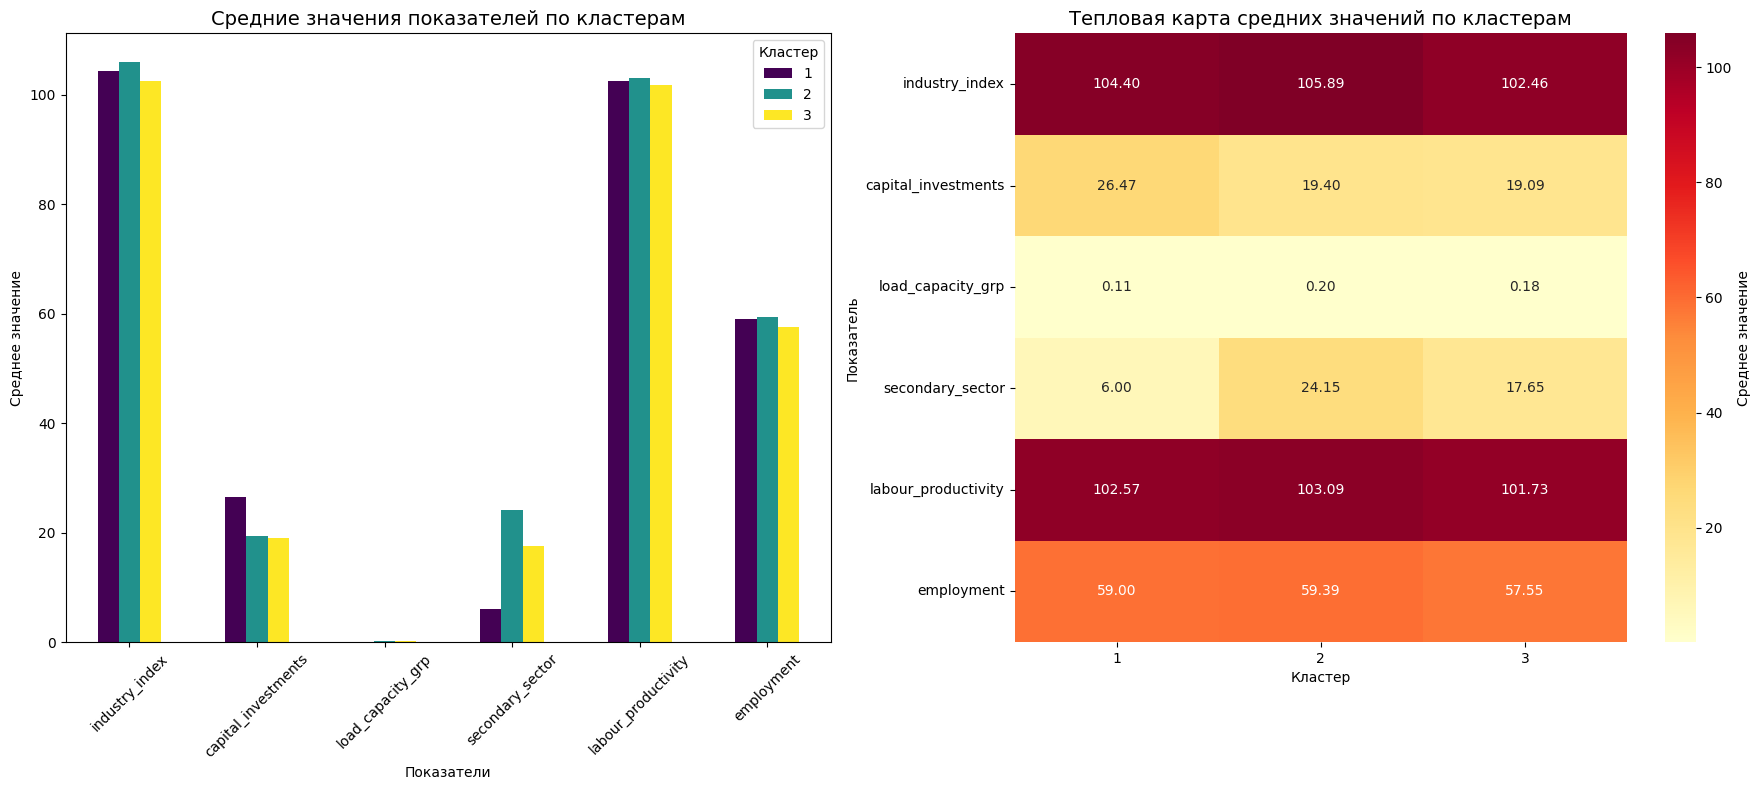

In [17]:
# Анализ средних значений в кластерах
cluster_profiles = average_df.groupby('cluster').mean()
cluster_profiles_scaled = scaled_average_df.groupby('cluster').mean()

# print("Средние значения показателей по кластерам (исходные):")
# print(cluster_profiles)

# print("\nСредние значения показателей по кластерам (стандартизованные):")
# print(cluster_profiles_scaled)

# Визуализация профилей кластеров
fig, axes = plt.subplots(1, 2, figsize=(18, 8))

# График 1: Средние значения в кластерах (исходные)
cluster_profiles.T.plot(kind='bar', ax=axes[0], colormap='viridis')
axes[0].set_title('Средние значения показателей по кластерам', fontsize=14)
axes[0].set_xlabel('Показатели')
axes[0].set_ylabel('Среднее значение')
axes[0].legend(title='Кластер')
axes[0].tick_params(axis='x', rotation=45)

# График 2: Heatmap средних значений
sns.heatmap(cluster_profiles.T, annot=True, fmt='.2f', cmap='YlOrRd', 
            ax=axes[1], cbar_kws={'label': 'Среднее значение'})
axes[1].set_title('Тепловая карта средних значений по кластерам', fontsize=14)
axes[1].set_xlabel('Кластер')
axes[1].set_ylabel('Показатель')
axes[1].tick_params(axis='y', rotation=0)

plt.tight_layout()
plt.show()

In [18]:
# Детальный анализ каждого кластера
for cluster_id in range(1, n_clusters + 1):
    cluster_regions = average_df[average_df['cluster'] == cluster_id].index.tolist()
    cluster_size = len(cluster_regions)
    
    print(f"\n{'='*60}")
    print(f"КЛАСТЕР {cluster_id} (регионов: {cluster_size})")
    print(f"{'='*60}")
    
    # Средние значения показателей для кластера
    cluster_mean = cluster_profiles.loc[cluster_id]
    
    print("\nСредние значения показателей:")
    for indicator, value in cluster_mean.items():
        print(f"  {indicator}: {value:.2f}")
    
    print("\nТипичные регионы (первые 10):")
    for region in cluster_regions[:10]:
        print(f"  - {region}")
    
    # Характеристика кластера
    print("\nХарактеристика кластера:")
    if cluster_mean['industry_index'] > cluster_profiles['industry_index'].mean():
        print("  • Высокий уровень промышленного производства")
    else:
        print("  • Низкий уровень промышленного производства")
    
    if cluster_mean['capital_investments'] > cluster_profiles['capital_investments'].mean():
        print("  • Высокий уровень инвестиций")
    else:
        print("  • Низкий уровень инвестиций")
    
    if cluster_mean['labour_productivity'] > cluster_profiles['labour_productivity'].mean():
        print("  • Высокая производительность труда")
    else:
        print("  • Низкая производительность труда")
    
    if cluster_mean['employment'] > cluster_profiles['employment'].mean():
        print("  • Высокий уровень занятости")
    else:
        print("  • Низкий уровень занятости")


КЛАСТЕР 1 (регионов: 26)

Средние значения показателей:
  industry_index: 104.40
  capital_investments: 26.47
  load_capacity_grp: 0.11
  secondary_sector: 6.00
  labour_productivity: 102.57
  employment: 59.00

Типичные регионы (первые 10):
  - Курская область
  - Ненецкий автономный округ
  - Республика Адыгея
  - Республика Крым
  - Город Севастополь
  - Республика Дагестан
  - Республика Ингушетия
  - Кабардино-Балкарская Республика
  - Карачаево-Черкесская Республика
  - Республика Северная Осетия-Алания

Характеристика кластера:
  • Высокий уровень промышленного производства
  • Высокий уровень инвестиций
  • Высокая производительность труда
  • Высокий уровень занятости

КЛАСТЕР 2 (регионов: 24)

Средние значения показателей:
  industry_index: 105.89
  capital_investments: 19.40
  load_capacity_grp: 0.20
  secondary_sector: 24.15
  labour_productivity: 103.09
  employment: 59.39

Типичные регионы (первые 10):
  - Брянская область
  - Владимирская область
  - Ивановская область


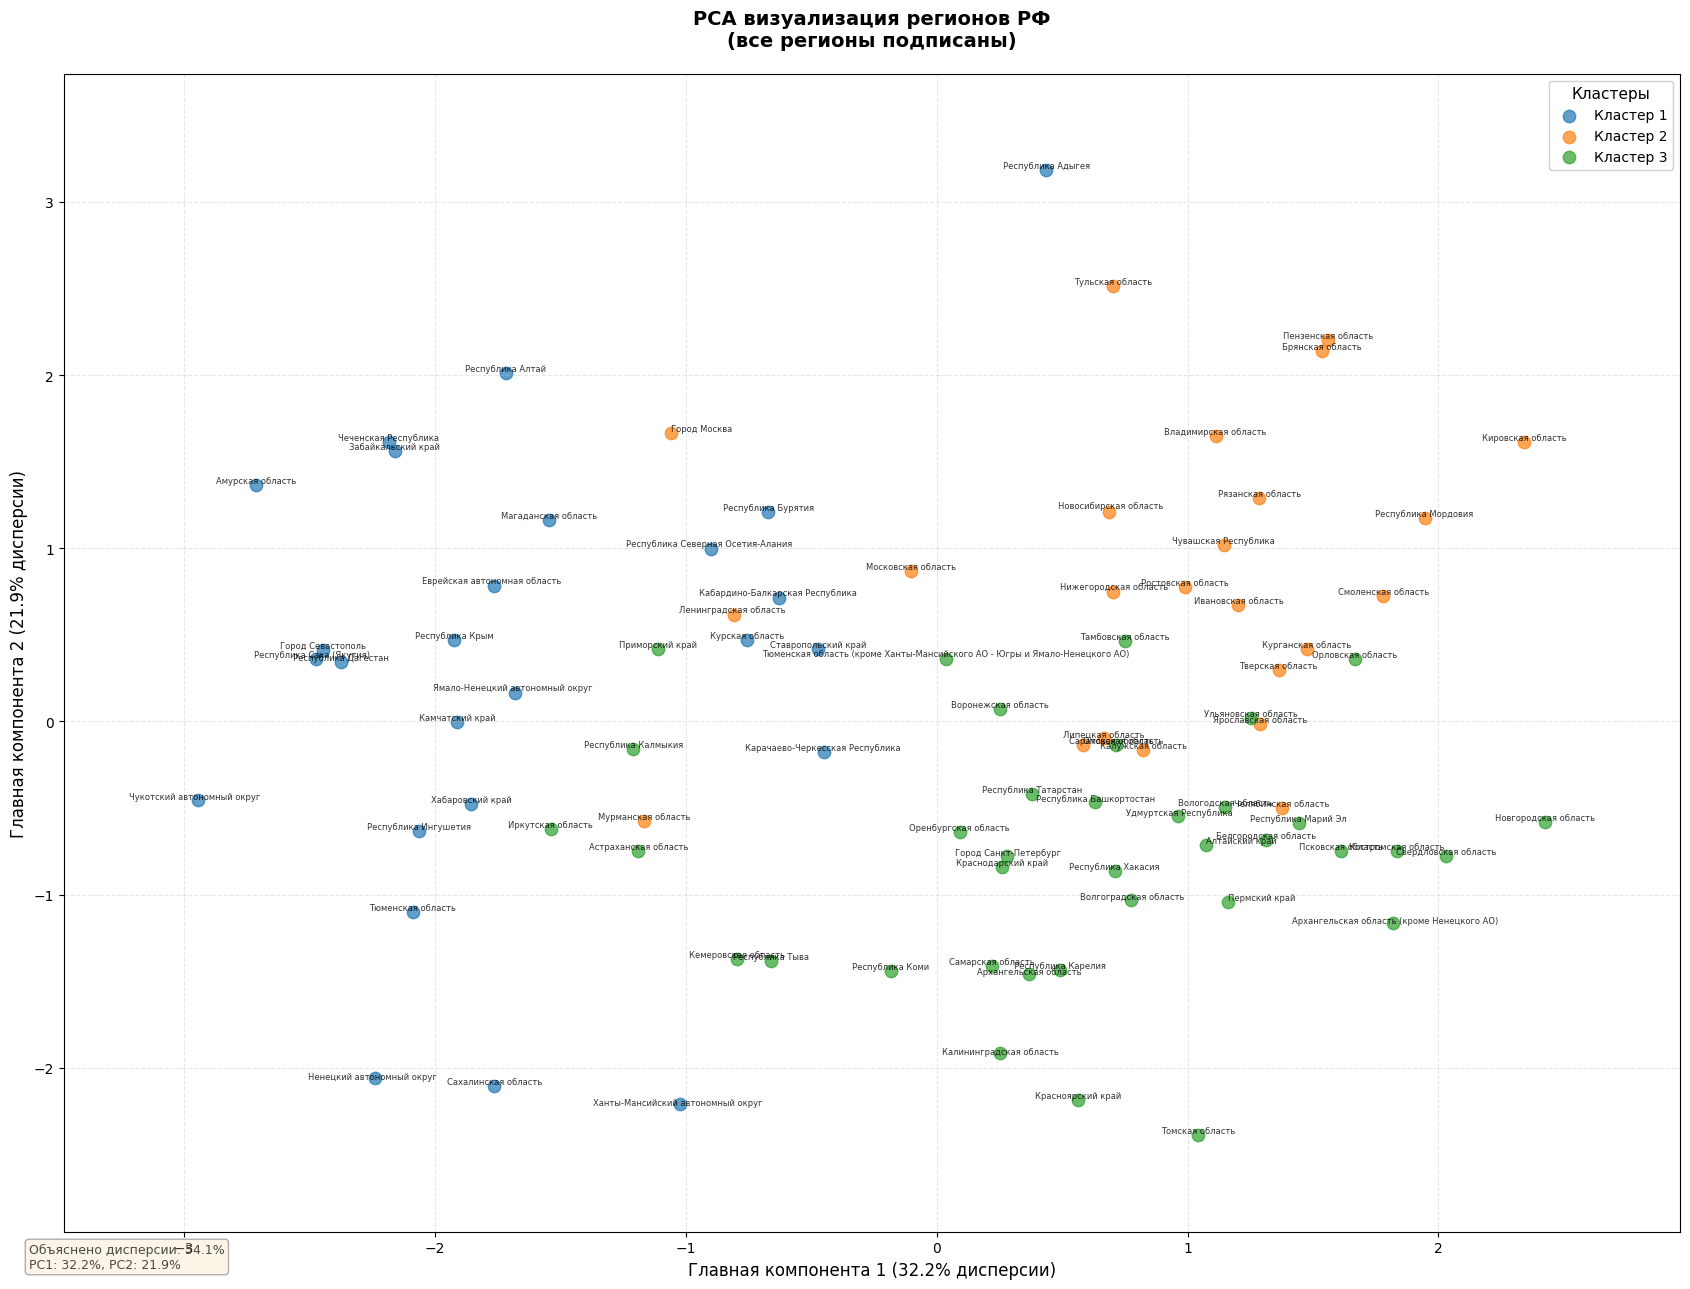

In [19]:
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA
import numpy as np

# 1. Уменьшение размерности до 2 компонент
pca = PCA(n_components=2, random_state=42)
pca_result = pca.fit_transform(scaled_average_df.iloc[:, :-1])  # Исключаем столбец 'cluster'

# 2. Создаем график
plt.figure(figsize=(17, 13))

# Настраиваем стиль для лучшей читаемости

# 3. Рисуем точки для каждого региона с цветами по кластерам (если есть)
if 'cluster' in scaled_average_df.columns:
    clusters = scaled_average_df['cluster']
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c']  # Цвета для 3 кластеров
    
    # Рисуем точки по кластерам
    for cluster_id in sorted(clusters.unique()):
        mask = clusters == cluster_id
        plt.scatter(pca_result[mask, 0], pca_result[mask, 1], 
                   color=colors[cluster_id-1], s=80, alpha=0.7,
                   label=f'Кластер {cluster_id}')
else:
    plt.scatter(pca_result[:, 0], pca_result[:, 1], 
               color='steelblue', s=80, alpha=0.7)

# 4. Подписываем ВСЕ регионы
for i, region in enumerate(scaled_average_df.index):
    # Определяем смещение для подписи, чтобы избежать наложений
    offset_x = 0.02 * (pca_result[i, 0].max() - pca_result[i, 0].min())
    offset_y = 0.02 * (pca_result[i, 1].max() - pca_result[i, 1].min())
    
    # Для регионов, которые слишком близко к другим, используем стрелки
    plt.annotate(
        region,
        xy=(pca_result[i, 0], pca_result[i, 1]),
        xytext=(pca_result[i, 0] + offset_x, pca_result[i, 1] + offset_y),
        fontsize=6,
        alpha=0.8,
        # Для длинных названий обрезаем
        textcoords='offset points' if len(region) > 20 else 'data',
        ha='left' if len(region) < 15 else 'center',
        va='bottom',
        # Добавляем стрелку для длинных названий
        arrowprops=dict(arrowstyle='->', color='gray', alpha=0.5, lw=0.5) if len(region) > 20 else None
    )

# 5. Подписываем оси с объяснением дисперсии
plt.xlabel(f'Главная компонента 1 ({pca.explained_variance_ratio_[0]*100:.1f}% дисперсии)', fontsize=12)
plt.ylabel(f'Главная компонента 2 ({pca.explained_variance_ratio_[1]*100:.1f}% дисперсии)', fontsize=12)

# 6. Добавляем заголовок
plt.title('PCA визуализация регионов РФ\n(все регионы подписаны)', fontsize=14, fontweight='bold', pad=20)

# 7. Добавляем легенду, если есть кластеры
if 'cluster' in scaled_average_df.columns:
    plt.legend(title='Кластеры', fontsize=10, title_fontsize=11, 
               loc='upper right', framealpha=0.9)

# 8. Добавляем сетку
plt.grid(True, alpha=0.3, linestyle='--')

# 9. Настраиваем границы для лучшего отображения
margin_x = (pca_result[:, 0].max() - pca_result[:, 0].min()) * 0.1
margin_y = (pca_result[:, 1].max() - pca_result[:, 1].min()) * 0.1
plt.xlim(pca_result[:, 0].min() - margin_x, pca_result[:, 0].max() + margin_x)
plt.ylim(pca_result[:, 1].min() - margin_y, pca_result[:, 1].max() + margin_y)

# 10. Добавляем информацию о PCA в углу
plt.figtext(0.02, 0.02, 
           f'Объяснено дисперсии: {pca.explained_variance_ratio_.sum()*100:.1f}%\n'
           f'PC1: {pca.explained_variance_ratio_[0]*100:.1f}%, '
           f'PC2: {pca.explained_variance_ratio_[1]*100:.1f}%',
           fontsize=9, alpha=0.7, bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.3))

plt.tight_layout()
plt.show()

In [20]:
## Формируем средние данные по кластерам
warnings.filterwarnings('ignore')
clustering_dict = average_df['cluster'].to_dict()
list_of_cluster_data = []
for cluster in range(1, 4):
    dict_for_df = {}
    for name, indicator in zip(indicator_names, the_whole_data):
        dict_for_df[name] = indicator.loc[indicator['Субъект'].map(lambda el: clustering_dict[el]) == cluster].iloc[:, 1:-1].mean(axis=0).tolist()
    df = pd.DataFrame(dict_for_df, index=np.arange(2018, 2024))
    list_of_cluster_data.append(df)

list_of_results_granger = []
for n, cluster_data in enumerate(list_of_cluster_data, start=1):
    list_for_df = []
    for indicator in indicator_names[:-1]:
        test_result = grangercausalitytests(cluster_data[['Уровень занятости', indicator]], maxlag=1,verbose=False)
        for lag, results in test_result.items():
            # Для SSR F-test берем второй элемент из кортежа (p-value)
            # Структура: (тестовая_статистика, p-value, степень_свободы)
            ssr_ftest = results[0]['ssr_ftest']
            # Получаем p-value
            p_value = ssr_ftest[1]
            list_for_df.append([indicator, p_value])
    list_of_results_granger.append(pd.DataFrame(list_for_df, columns=['Показатель', 'p-value']))

for n, df_res in enumerate(list_of_results_granger, start=1):
    print(f'Тест Грейнджера на 1 лаг для каждой переменной для кластера {n}')
    print(df_res)
    print()






Тест Грейнджера на 1 лаг для каждой переменной для кластера 1
                          Показатель   p-value
0  Индекс промышленного производства  0.780419
1      Инвестиции в основной капитал  0.948797
2                   Грузоёмкость ВРП  0.262632
3    Доля обрабатывающих производств  0.294116
4           Производительность труда  0.279241

Тест Грейнджера на 1 лаг для каждой переменной для кластера 2
                          Показатель   p-value
0  Индекс промышленного производства  0.757883
1      Инвестиции в основной капитал  0.554517
2                   Грузоёмкость ВРП  0.118689
3    Доля обрабатывающих производств  0.425059
4           Производительность труда  0.369106

Тест Грейнджера на 1 лаг для каждой переменной для кластера 3
                          Показатель   p-value
0  Индекс промышленного производства  0.531486
1      Инвестиции в основной капитал  0.569285
2                   Грузоёмкость ВРП  0.009933
3    Доля обрабатывающих производств  0.325134
4           П

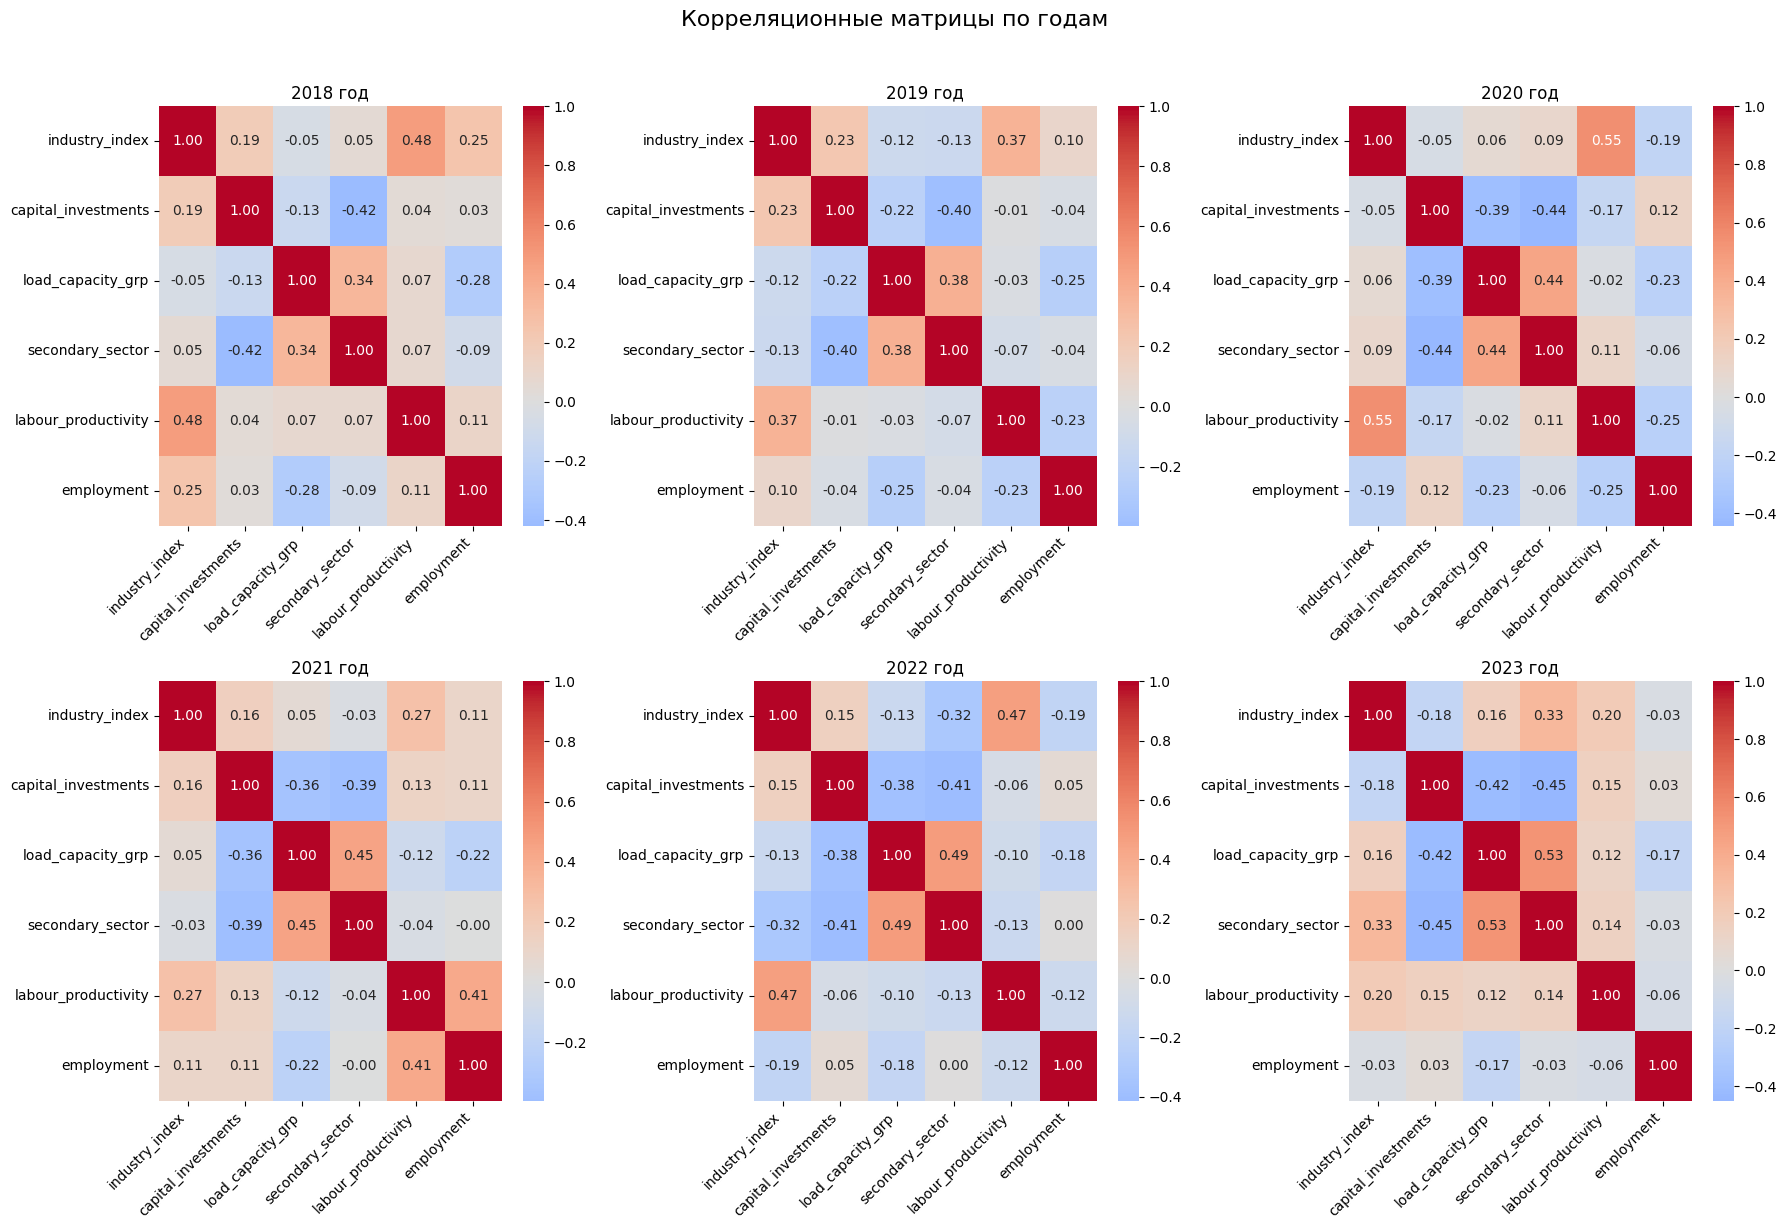

In [21]:
for year in range(2018, 2024):
    df = pd.DataFrame(np.array([df[year].to_list() for df in the_whole_data]).T, index=employment['Субъект'], columns=string_indicators).corr()
    
fig, axes = plt.subplots(2, 3, figsize=(18, 12))
plt.suptitle('Корреляционные матрицы по годам', fontsize=16, y=1.02)

for idx, year in enumerate(range(2018, 2024)):
    ax = axes[idx//3, idx%3]
    df_corr = pd.DataFrame(
        np.array([df[year].to_list() for df in the_whole_data]).T,
        index=employment['Субъект'],
        columns=string_indicators
    ).corr()
    
    sns.heatmap(df_corr, ax=ax, annot=True, fmt='.2f', cmap='coolwarm', center=0)
    ax.set_title(f'{year} год')
    ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')

plt.tight_layout()
plt.show()

Text(0.5, 1.0, 'Матрица коэффициентов корреляций по средним данным за последние 5 лет\n')

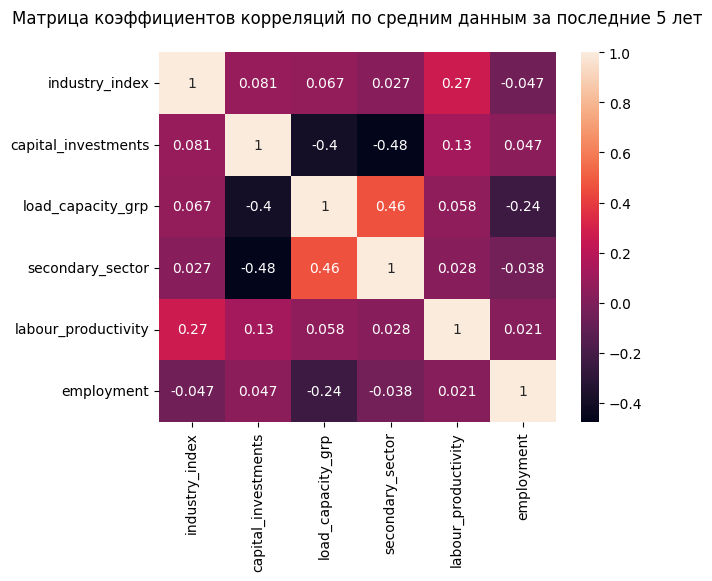

In [22]:
sns.heatmap(scaled_average_df.iloc[:,:-1].corr(), annot=True)
plt.title('Матрица коэффициентов корреляций по средним данным за последние 5 лет\n')
# load_capacity_grp and industry_index

In [23]:
def build_regression_for_cluster(indicators, cluster):
    X = []
    for i, indicator in enumerate(indicators):
        cluster_mask = indicator['Субъект'].map(lambda region: clustering_dict[region] == cluster)
        indicator_row = indicator.loc[cluster_mask].iloc[:, 1:-1].mean(axis=0).tolist()
        X.append(indicator_row)
    y = employment.loc[cluster_mask].iloc[:, 1:-1].mean(axis=0).to_numpy()
    X = np.array(X).T

    model = LinearRegression()
    model.fit(X, y)
    model_quality = r2_score(y, model.predict(X))

    n = X.shape[0]
    p = X.shape[1]
    dof = n - p - 1
    residuals = y - model.predict(X)

    rss = np.sum(residuals ** 2)

    sigma_squared = rss / dof

    X_with_intercept = np.hstack([np.ones((n, 1)), X])
    xtx_inv = np.linalg.inv(X_with_intercept.T @ X_with_intercept)

    se = np.sqrt(np.diag(xtx_inv) * sigma_squared)

    t_values = np.hstack([model.intercept_, model.coef_]) / se
    p_values = 2 * (1 - sps.t.cdf(np.abs(t_values), dof))

    print(f'Cluster №{cluster}')
    print(f'R2 = {np.round(model_quality * 100, 2)}%')
    for i, (coef, se_val, t_val, p_val) in enumerate(zip(
        np.hstack([model.intercept_, model.coef_]), se, t_values, p_values)):
        if i == 0:
            print(f"Intercept: coef={coef:.4f}, se={se_val:.4f}, t={t_val:.4f}, p={p_val:.4f}")
        else:
            print(f"X{i}: coef={coef:.4f}, se={se_val:.4f}, t={t_val:.4f}, p={p_val:.4f}")
    print('='*60)
    print('\n')


In [24]:
for cluster in range(1, 4):
    for r in range(1, len(the_whole_data[:-1]) + 1):
        for names, element in zip(itertools.combinations(string_indicators[:-1], r),
                                   itertools.combinations(the_whole_data[:-1], r)):
            print('ПЕРЕМЕННЫЕ', names)
            build_regression_for_cluster(element, cluster)

ПЕРЕМЕННЫЕ ('industry_index',)
Cluster №1
R2 = 21.72%
Intercept: coef=44.0745, se=14.1676, t=3.1109, p=0.0358
X1: coef=0.1429, se=0.1357, t=1.0534, p=0.3516


ПЕРЕМЕННЫЕ ('capital_investments',)
Cluster №1
R2 = 21.85%
Intercept: coef=53.6745, se=5.0401, t=10.6495, p=0.0004
X1: coef=0.2011, se=0.1901, t=1.0574, p=0.3499


ПЕРЕМЕННЫЕ ('load_capacity_grp',)
Cluster №1
R2 = 22.68%
Intercept: coef=64.5888, se=5.1705, t=12.4917, p=0.0002
X1: coef=-50.2011, se=46.3454, t=-1.0832, p=0.3397


ПЕРЕМЕННЫЕ ('secondary_sector',)
Cluster №1
R2 = 30.42%
Intercept: coef=51.4234, se=5.7326, t=8.9704, p=0.0009
X1: coef=1.2618, se=0.9542, t=1.3224, p=0.2566


ПЕРЕМЕННЫЕ ('labour_productivity',)
Cluster №1
R2 = 23.74%
Intercept: coef=40.2403, se=16.8114, t=2.3936, p=0.0749
X1: coef=0.1829, se=0.1639, t=1.1158, p=0.3270


ПЕРЕМЕННЫЕ ('industry_index', 'capital_investments')
Cluster №1
R2 = 57.6%
Intercept: coef=32.2255, se=14.1519, t=2.2771, p=0.1072
X1: coef=0.1891, se=0.1189, t=1.5903, p=0.2100
X2: coef=

In [25]:
build_regression_for_cluster([industry_index, secondary_sector], 1)
build_regression_for_cluster([industry_index, capital_investments, load_capacity_grp], 2)
build_regression_for_cluster([load_capacity_grp, secondary_sector, labour_productivity], 3)

Cluster №1
R2 = 80.49%
Intercept: coef=23.5039, se=10.6534, t=2.2062, p=0.1145
X1: coef=0.2321, se=0.0836, t=2.7752, p=0.0693
X2: coef=1.8760, se=0.6239, t=3.0066, p=0.0574


Cluster №2
R2 = 96.67%
Intercept: coef=-2.9808, se=9.8489, t=-0.3027, p=0.7907
X1: coef=0.4376, se=0.0594, t=7.3709, p=0.0179
X2: coef=2.0861, se=0.4020, t=5.1895, p=0.0352
X3: coef=-124.4766, se=20.2490, t=-6.1473, p=0.0255


Cluster №3
R2 = 91.39%
Intercept: coef=42.1484, se=14.1508, t=2.9785, p=0.0967
X1: coef=-28.7532, se=13.7933, t=-2.0846, p=0.1725
X2: coef=-1.5127, se=0.5846, t=-2.5877, p=0.1225
X3: coef=0.4660, se=0.1226, t=3.8020, p=0.0627




In [26]:
for cluster, df in enumerate(list_of_cluster_data, start=1):
    print(f"Кластер № {cluster}")
    y = df['Уровень занятости'].to_numpy()
    X = df.iloc[:, :-1].to_numpy().T
    lst = []
    for r in range(1, 6):
        for name, data in zip(itertools.combinations(string_indicators, r), itertools.combinations(X, r)):
            exog = pd.DataFrame(np.array(data).T, columns=name)
            exog_with_const = sm.add_constant(exog)
            model_sm = sm.OLS(y, exog_with_const)
            results = model_sm.fit()
            if all(x[1] < 0.15 for x in results.pvalues.items()):
                lst.append([', '.join(name), results.rsquared, results.rsquared_adj, results.pvalues])

    for n, (name, rsquared, rsquared_adj, pvalues) in enumerate(sorted(lst, key=lambda el: el[2], reverse=True), start=1):
        print(n)
        print(f'Переменные: {name}')
        print(f'R2_adj = {round(rsquared_adj*100, 2)}')
        for coef, pvalue in pvalues.items():
            print(f'p-value of {coef} = {round(pvalue, 4)}')
        print()
        if n == 5:
            break
        

Кластер № 1
1
Переменные: industry_index, load_capacity_grp, secondary_sector
R2_adj = 78.53
p-value of const = 0.03
p-value of industry_index = 0.133
p-value of load_capacity_grp = 0.0624
p-value of secondary_sector = 0.0635

2
Переменные: industry_index, secondary_sector
R2_adj = 67.49
p-value of const = 0.1145
p-value of industry_index = 0.0693
p-value of secondary_sector = 0.0574

Кластер № 2
1
Переменные: industry_index, capital_investments, load_capacity_grp, secondary_sector
R2_adj = 99.98
p-value of const = 0.0288
p-value of industry_index = 0.0052
p-value of capital_investments = 0.0096
p-value of load_capacity_grp = 0.0071
p-value of secondary_sector = 0.0208

2
Переменные: industry_index, load_capacity_grp, labour_productivity
R2_adj = 71.69
p-value of const = 0.0358
p-value of industry_index = 0.0894
p-value of load_capacity_grp = 0.0894
p-value of labour_productivity = 0.1499

Кластер № 3
1
Переменные: load_capacity_grp, secondary_sector
R2_adj = 54.45
p-value of const = 0

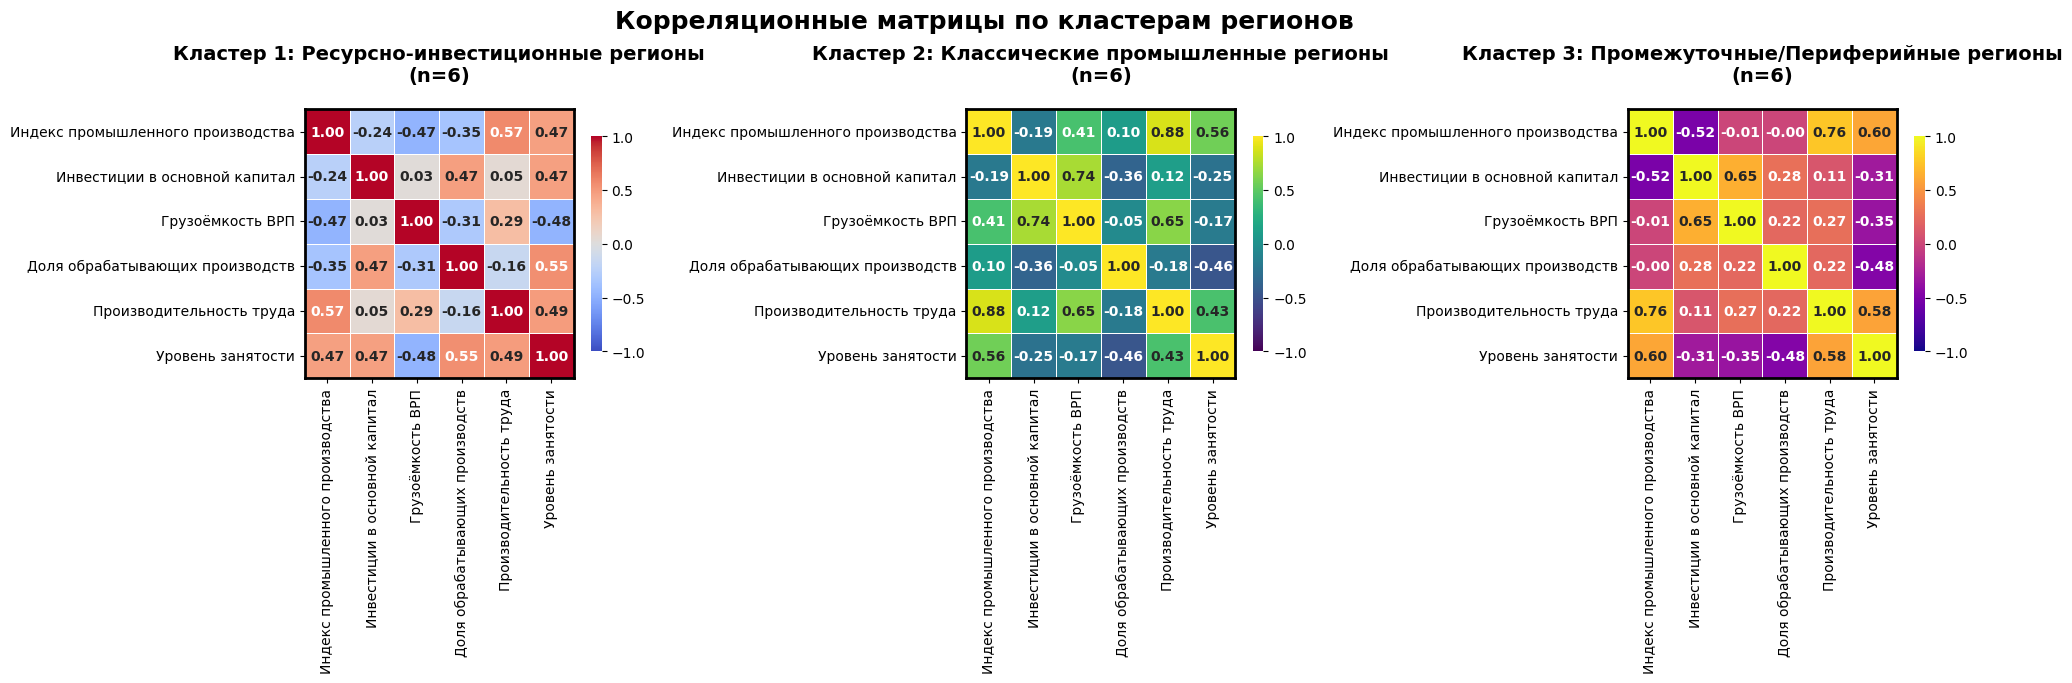

In [32]:
# Создаем фигуру с тремя subplot (горизонтальное расположение)
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# Цветовые палитры для каждого кластера
palettes = ['coolwarm', 'viridis', 'plasma']

# Аннотации для каждого кластера
cluster_names = ['Кластер 1: Ресурсно-инвестиционные регионы', 
                'Кластер 2: Классические промышленные регионы', 
                'Кластер 3: Промежуточные/Периферийные регионы']

for i, df in enumerate(list_of_cluster_data, start=1):
    # Вычисляем корреляционную матрицу
    corr_matrix = df.corr()
    
    # Создаем heatmap для текущего кластера
    sns.heatmap(corr_matrix, 
                ax=axes[i-1],
                cmap=palettes[i-1],
                annot=True,
                fmt=".2f",
                linewidths=0.5,
                linecolor='white',
                square=True,
                cbar_kws={"shrink": 0.8},
                center=0,  # центр цветовой шкалы на 0
                vmin=-1, vmax=1,  # фиксированный диапазон для сравнения
                annot_kws={"size": 10, "weight": "bold"})
    
    # Настройка заголовка и внешнего вида
    axes[i-1].set_title(f'{cluster_names[i-1]}\n(n={len(df)})', 
                       fontsize=14, fontweight='bold', pad=20)
    axes[i-1].tick_params(axis='x', rotation=90, labelsize=10)
    axes[i-1].tick_params(axis='y', labelsize=10)
    
    # Добавляем рамку
    for _, spine in axes[i-1].spines.items():
        spine.set_visible(True)
        spine.set_linewidth(2)
        spine.set_edgecolor('black')

# Общий заголовок для всех графиков
fig.suptitle('Корреляционные матрицы по кластерам регионов', 
             fontsize=18, fontweight='bold', y=1.05)

# Настраиваем расположение
plt.tight_layout()
plt.show()

In [28]:
list_of_cluster_data[0].head()

,Индекс промышленного производства,Инвестиции в основной капитал,Грузоёмкость ВРП,Доля обрабатывающих производств,Производительность труда,Уровень занятости
2018,102.748462,26.267692,0.112732,6.298462,102.558462,59.372308
2019,105.512308,26.924615,0.113515,5.586923,102.965385,58.867692
2020,101.217692,26.258462,0.121122,5.896154,101.584615,57.878462
2021,107.373846,23.695385,0.108171,5.746923,103.636154,58.844615
2022,103.820000,27.100769,0.101367,6.236923,99.663846,59.057692
